In [ ]:
from pywswat import mikeio as mikewave
import mikeio

## Input file

In [2]:
fn_sample = r"D:\STKI\M21WFM\Examples\Ronne\Tri_irregular_3d_refined.mwfm - Result Files\area.dfsu"
ds_u = mikeio.read(fn_sample)

Plot

<Axes: title={'center': '1990-01-01 12:35:00'}, xlabel='Easting [m]', ylabel='Northing [m]'>

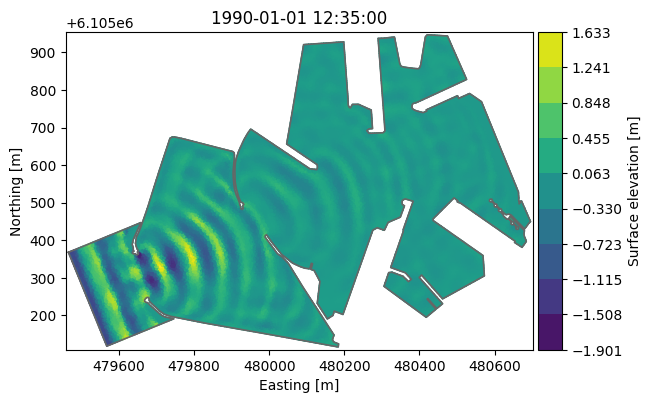

In [3]:
ds_u["Surface elevation"].isel(time=-1).plot()

## Time/space
Start/end

<Axes: title={'center': '1990-01-01 12:35:00'}, xlabel='Easting [m]', ylabel='Northing [m]'>

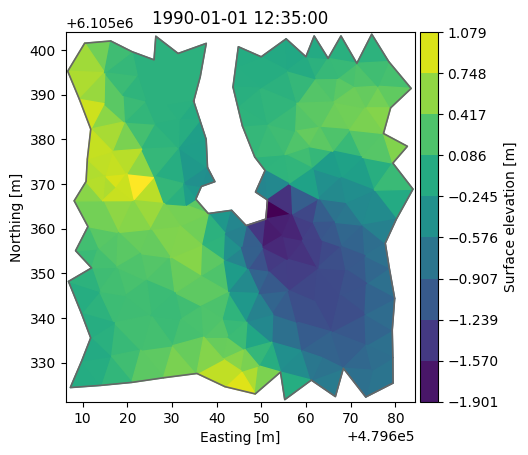

In [7]:
ds_u_sub = mikewave.subset_area(ds_u, (479610, 6105325, 479680, 6105400))
ds_u_sub["Surface elevation"].isel(time=-1).plot()

## FFT Parameters

Resolution

In [8]:
fft_size = 256

Data window

In [9]:
window_type = "hann"
overlap = 0.5

Cut-off frequency

In [10]:
f0 = None
f1 = 0.125

## Analysis

In [11]:
itm_se = "Surface elevation"
itm_u = "Depth averaged U velocity"
itm_v = "Depth averaged V velocity"

In [12]:
ds = mikewave.spectral_params(
    ds_u_sub,
    elevation=itm_se,
    u=itm_u,
    v=itm_v,
    window=window_type,
    overlap=overlap,
    window_size=fft_size,
    fmin=f0,
    fmax=9999,
)

Computing MEM spectrum at spatial locations: 100%|██████████| 286/286 [00:02<00:00, 100.86it/s]


<Axes: title={'center': '1990-01-01 12:00:00'}, xlabel='Easting [m]', ylabel='Northing [m]'>

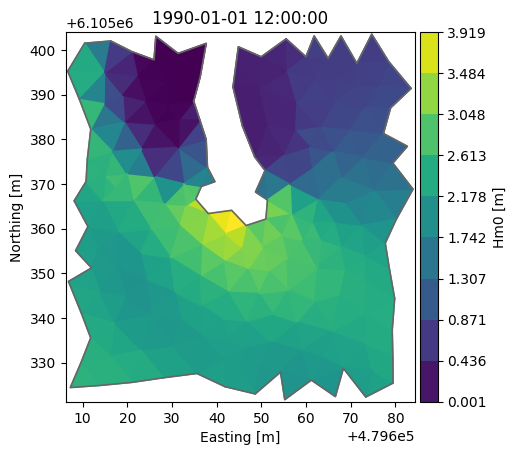

In [13]:
ds["Hm0"].plot()

In [14]:
ds

<mikeio.Dataset>
dims: (time:1, element:286)
time: 1990-01-01 12:00:00 (time-invariant)
geometry: Dfsu2D (286 elements, 182 nodes)
items:
  0:  Hm0 <Significant wave height> (meter)
  1:  Tp <Wave period> (second)
  2:  T01 <Wave period> (second)
  3:  T02 <Wave period> (second)
  4:  Tm10 <Wave period> (second)
  5:  MWD <Mean Wave Direction> (degree)
  6:  PWD <Wave direction> (degree)
  7:  DSD <Directional Standard Deviation> (degree)